In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from pathlib import Path

repo_root = Path.cwd().parent
figures_dir = repo_root / "figures"

figures_dir.mkdir(exist_ok=True)

print(figures_dir)

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures


# Linear-Response Validation

This notebook validates the direct frequency-domain resolvent method
for the coupled thermal dimer.

The validation is performed in two stages:

1. Compare direct numerical integration of the Lindblad master equation
   with propagation generated by the Liouvillian,

$$
\rho_{\mathrm{ODE}}(t)
\stackrel{?}{=}
\operatorname{unvec}
\left[
e^{\mathcal{L}t}|\rho_0\rangle\rangle
\right].
$$

2. Compare the numerical Fourier transform of the time-domain linear
response,

$$
R^{(1)}(t)
=
\langle\!\langle\mu|
e^{\mathcal{L}t}
V
|\rho_0\rangle\rangle,
$$

with the direct frequency-domain result,

$$
M^{(1)}(\omega)
=
\langle\!\langle\mu|
G(\omega)
V
|\rho_0\rangle\rangle,
$$

where

$$
G(\omega)
=
\left[
(\eta-i\omega)I-\mathcal{L}
\right]^{-1}.
$$

In [3]:
import numpy as np

from src.dimer_model import (
    build_dimer,
    vec,
    unvec,
    stationary_state,
)

In [4]:
model = build_dimer()

H_S = model["H_S"]
mu = model["mu"]
L_super = model["L_super"]
V = model["V"]
rho0 = model["rho0"]

print("H_S shape:", H_S.shape)
print("L_super shape:", L_super.shape)
print("V shape:", V.shape)

H_S shape: (4, 4)
L_super shape: (16, 16)
V shape: (16, 16)


## 2. Direct Lindblad ODE versus Liouvillian propagation

Before testing the frequency-domain resolvent, we verify that the
Liouville-space representation generates the same dynamics as the
original Lindblad master equation.

The density-matrix equation is

$$
\frac{d\rho}{dt}
=
-\frac{i}{\hbar}[H_S,\rho]
+
\sum_k
\left(
L_k\rho L_k^\dagger
-
\frac{1}{2}
\{L_k^\dagger L_k,\rho\}
\right).
$$

We compare a direct numerical ODE solution of this equation with

$$
|\rho(t)\rangle\rangle
=
e^{\mathcal{L}t}
|\rho_0\rangle\rangle.
$$

In [5]:
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from numpy.linalg import norm

In [6]:
hbar = model["hbar"]

L_a_down = model["L_a_down"]
L_a_up = model["L_a_up"]
L_b_down = model["L_b_down"]
L_b_up = model["L_b_up"]

jump_operators = [
    L_a_down,
    L_a_up,
    L_b_down,
    L_b_up,
]

In [7]:
def dissipator_rho(L, rho):
    """
    Hilbert-space Lindblad dissipator.
    """
    LdagL = L.conj().T @ L

    return (
        L @ rho @ L.conj().T
        - 0.5 * (LdagL @ rho + rho @ LdagL)
    )

In [8]:
def lindblad_rhs(t, rho_vec):
    """
    Direct Lindblad master equation used by solve_ivp.

    This implementation acts directly on the density matrix
    and does not use L_super.
    """

    rho = unvec(rho_vec, 4)

    # Hamiltonian contribution
    drho = (
        -1j / hbar
        * (H_S @ rho - rho @ H_S)
    )

    # Dissipative contributions
    for L in jump_operators:
        drho += dissipator_rho(L, rho)

    return vec(drho)

In [9]:
t_max = 100.0
n_times = 501

times = np.linspace(0.0, t_max, n_times)

print("dt =", times[1] - times[0])
print("t_max =", times[-1])

dt = 0.2
t_max = 100.0


In [10]:
solution_ode = solve_ivp(
    lindblad_rhs,
    t_span=(0.0, t_max),
    y0=vec(rho0),
    t_eval=times,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

print("ODE solver successful:", solution_ode.success)
print("Message:", solution_ode.message)

ODE solver successful: True
Message: The solver successfully reached the end of the integration interval.


In [11]:
rho0_vec = vec(rho0)

rho_liouvillian = []

for t in times:
    rho_t_vec = expm(L_super * t) @ rho0_vec
    rho_liouvillian.append(rho_t_vec)

rho_liouvillian = np.array(rho_liouvillian)

In [12]:
print(rho_liouvillian.shape)

(501, 16)


In [13]:
rho_ode = solution_ode.y.T

print("ODE trajectory shape:        ", rho_ode.shape)
print("Liouvillian trajectory shape:", rho_liouvillian.shape)

ODE trajectory shape:         (501, 16)
Liouvillian trajectory shape: (501, 16)


In [14]:
trajectory_errors = np.linalg.norm(
    rho_ode - rho_liouvillian,
    axis=1
)

print("Maximum trajectory error =", np.max(trajectory_errors))
print("Final-time error         =", trajectory_errors[-1])

Maximum trajectory error = 1.8436926596309847e-11
Final-time error         = 6.458295840328181e-13


In [15]:
relative_trajectory_errors = []

for ode_vec, liou_vec in zip(rho_ode, rho_liouvillian):

    denominator = norm(liou_vec)

    relative_trajectory_errors.append(
        norm(ode_vec - liou_vec) / denominator
    )

relative_trajectory_errors = np.array(relative_trajectory_errors)

print(
    "Maximum relative trajectory error =",
    np.max(relative_trajectory_errors)
)

Maximum relative trajectory error = 2.0154429908011836e-11


In [16]:
rho_ode_matrices = np.array([
    unvec(rho_vec, 4)
    for rho_vec in rho_ode
])

rho_liouvillian_matrices = np.array([
    unvec(rho_vec, 4)
    for rho_vec in rho_liouvillian
])

In [17]:
pop_gg_ode = np.real(rho_ode_matrices[:, 0, 0])
pop_eg_ode = np.real(rho_ode_matrices[:, 1, 1])
pop_ge_ode = np.real(rho_ode_matrices[:, 2, 2])
pop_ee_ode = np.real(rho_ode_matrices[:, 3, 3])

pop_gg_L = np.real(rho_liouvillian_matrices[:, 0, 0])
pop_eg_L = np.real(rho_liouvillian_matrices[:, 1, 1])
pop_ge_L = np.real(rho_liouvillian_matrices[:, 2, 2])
pop_ee_L = np.real(rho_liouvillian_matrices[:, 3, 3])

In [18]:
import matplotlib.pyplot as plt

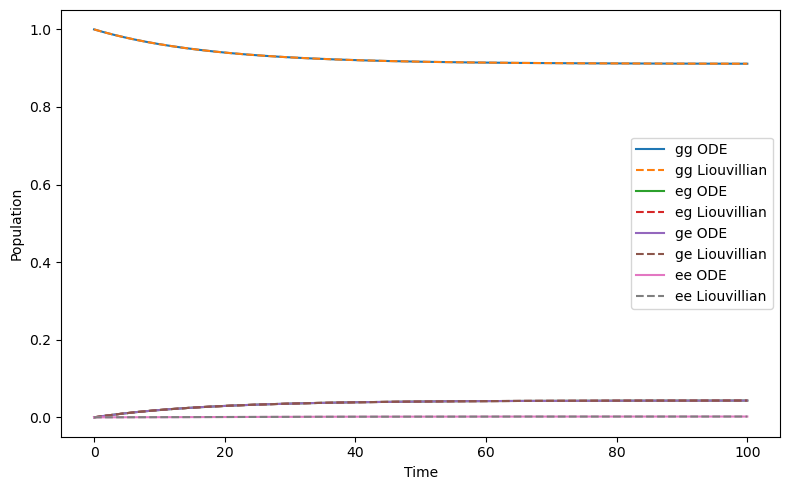

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(times, pop_gg_ode, label="gg ODE")
plt.plot(times, pop_gg_L, "--", label="gg Liouvillian")

plt.plot(times, pop_eg_ode, label="eg ODE")
plt.plot(times, pop_eg_L, "--", label="eg Liouvillian")

plt.plot(times, pop_ge_ode, label="ge ODE")
plt.plot(times, pop_ge_L, "--", label="ge Liouvillian")

plt.plot(times, pop_ee_ode, label="ee ODE")
plt.plot(times, pop_ee_L, "--", label="ee Liouvillian")

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
evals_L, evecs_L = np.linalg.eig(L_super)

idx_zero = np.argmin(np.abs(evals_L))

rho_ss = unvec(evecs_L[:, idx_zero], 4)
rho_ss = rho_ss / np.trace(rho_ss)

In [21]:
rho_final = rho_liouvillian_matrices[-1]

print(
    "Distance from stationary state at t_max =",
    norm(rho_final - rho_ss)
)

Distance from stationary state at t_max = 0.0004279448337675835


## 3. Time-domain linear response

The first-order response is generated by one interaction with the
electric field.

Starting from the initial state $|\rho_0\rangle\rangle$, the first
interaction produces

$$
|\rho^{(1)}(0)\rangle\rangle
=
V|\rho_0\rangle\rangle.
$$

The resulting first-order operator evolves under the field-free
Liouvillian,

$$
|\rho^{(1)}(t)\rangle\rangle
=
e^{\mathcal{L}t}
V|\rho_0\rangle\rangle.
$$

The linear molecular response is

$$
R^{(1)}(t)
=
\langle\!\langle\mu|
e^{\mathcal{L}t}
V|\rho_0\rangle\rangle.
$$

We compare this response obtained from Liouvillian propagation with
a direct numerical integration of the Lindblad master equation.

In [22]:
rho1_0_vec = V @ vec(rho0)
rho1_0 = unvec(rho1_0_vec, 4)

print("First-order operator after one interaction:")
print(rho1_0)

First-order operator after one interaction:
[[0.+0.j 0.-1.j 0.-1.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [23]:
print("Trace of rho1_0 =", np.trace(rho1_0))

Trace of rho1_0 = 0j


In [24]:
print(
    "rho1_0 Hermiticity error =",
    norm(rho1_0 - rho1_0.conj().T)
)

rho1_0 Hermiticity error = 0.0


In [25]:
solution_rho1_ode = solve_ivp(
    lindblad_rhs,
    t_span=(0.0, t_max),
    y0=rho1_0_vec,
    t_eval=times,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

print("First-order ODE successful:", solution_rho1_ode.success)

First-order ODE successful: True


In [26]:
rho1_ode = solution_rho1_ode.y.T

print("rho1 ODE shape:", rho1_ode.shape)

rho1 ODE shape: (501, 16)


In [27]:
rho1_liouvillian = []

for t in times:
    rho1_t_vec = expm(L_super * t) @ rho1_0_vec
    rho1_liouvillian.append(rho1_t_vec)

rho1_liouvillian = np.array(rho1_liouvillian)

print(
    "rho1 Liouvillian shape:",
    rho1_liouvillian.shape
)

rho1 Liouvillian shape: (501, 16)


In [28]:
rho1_errors = np.linalg.norm(
    rho1_ode - rho1_liouvillian,
    axis=1
)

print(
    "Maximum first-order trajectory error =",
    np.max(rho1_errors)
)

print(
    "Final first-order trajectory error =",
    rho1_errors[-1]
)

Maximum first-order trajectory error = 3.9865347298234165e-10
Final first-order trajectory error = 1.6040904037678801e-10


In [29]:
mu_bra = vec(mu).conj()

print("mu_bra shape:", mu_bra.shape)

mu_bra shape: (16,)


In [30]:
R1_ode = np.array([
    mu_bra @ rho_vec
    for rho_vec in rho1_ode
])

In [31]:
R1_liouvillian = np.array([
    mu_bra @ rho_vec
    for rho_vec in rho1_liouvillian
])

In [32]:
print(
    "Largest imaginary part, ODE =",
    np.max(np.abs(np.imag(R1_ode)))
)

print(
    "Largest imaginary part, Liouvillian =",
    np.max(np.abs(np.imag(R1_liouvillian)))
)

Largest imaginary part, ODE = 2.220446049250313e-16
Largest imaginary part, Liouvillian = 1.4432899320127035e-15


In [33]:
R1_difference = R1_ode - R1_liouvillian

print(
    "Maximum response difference =",
    np.max(np.abs(R1_difference))
)

Maximum response difference = 7.342397800869176e-10


In [34]:
R1_relative_L2_error = (
    norm(R1_ode - R1_liouvillian)
    / norm(R1_liouvillian)
)

print(
    "Relative L2 response error =",
    R1_relative_L2_error
)

Relative L2 response error = 3.410712014015115e-10


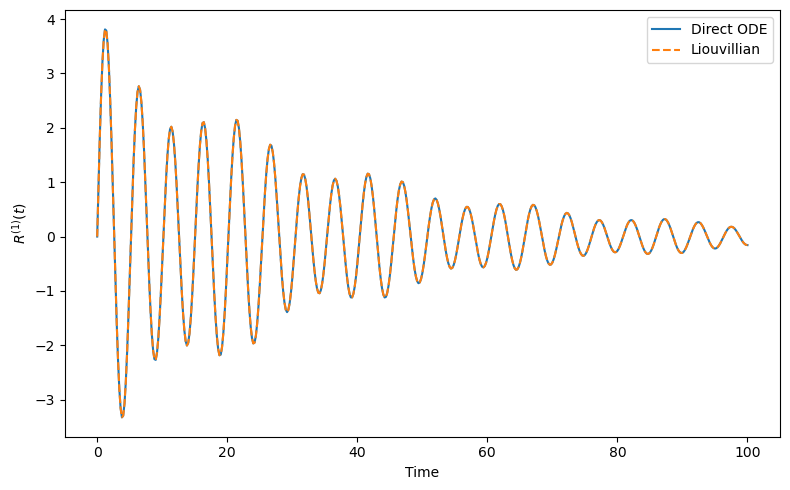

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    times,
    np.real(R1_ode),
    label="Direct ODE"
)

plt.plot(
    times,
    np.real(R1_liouvillian),
    "--",
    label="Liouvillian"
)

plt.xlabel("Time")
plt.ylabel(r"$R^{(1)}(t)$")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
print("R1(0) =", R1_liouvillian[0])
print("R1(t_max) =", R1_liouvillian[-1])

R1(0) = 0j
R1(t_max) = (-0.15696936708103443-1.1709383462843448e-17j)


## 4. Time-domain Fourier transform versus direct resolvent

Our Fourier-transform convention is

$$
f(\omega)
=
\int_{-\infty}^{+\infty}
dt\,
e^{i\omega t}f(t).
$$

The linear response is causal. If it is extended to the full time axis,

$$
R_{\mathrm{causal}}^{(1)}(t)
=
\Theta(t)
\langle\!\langle\mu|
e^{\mathcal{L}t}
V
|\rho_0\rangle\rangle.
$$

Therefore,

$$
\begin{aligned}
M_{\mathrm{TD}}^{(1)}(\omega)
&=
\int_{-\infty}^{+\infty}
dt\,
e^{i\omega t}
e^{-\eta t}
R_{\mathrm{causal}}^{(1)}(t)
\\
&=
\int_0^\infty
dt\,
e^{i\omega t}
e^{-\eta t}
R^{(1)}(t).
\end{aligned}
$$

Here

$$
R^{(1)}(t)
=
\langle\!\langle\mu|
e^{\mathcal{L}t}
V
|\rho_0\rangle\rangle,
\qquad t\ge0.
$$

The causal time integral gives

$$
\int_0^\infty dt\,
e^{(\mathcal{L}+i\omega I-\eta I)t}
=
\left[
(\eta-i\omega)I-\mathcal{L}
\right]^{-1}.
$$

Thus,

$$
M_{\mathrm{FD}}^{(1)}(\omega)
=
\langle\!\langle\mu|
G(\omega)
V
|\rho_0\rangle\rangle,
$$

with

$$
G(\omega)
=
\left[
(\eta-i\omega)I-\mathcal{L}
\right]^{-1}.
$$

The same finite value of $\eta$ must be used in the time-domain
integral and in the direct resolvent calculation.

In [37]:
eta = 0.02

dt_ft = 0.02
t_max_ft = 250.0

times_ft = np.arange(
    0.0,
    t_max_ft + dt_ft,
    dt_ft
)

print("Number of FT time points =", len(times_ft))
print("dt =", dt_ft)
print("t_max =", times_ft[-1])
print("eta =", eta)

Number of FT time points = 12501
dt = 0.02
t_max = 250.0
eta = 0.02


In [38]:
from scipy.sparse.linalg import expm_multiply

In [39]:
rho1_ft_liouvillian = expm_multiply(
    L_super,
    rho1_0_vec,
    start=0.0,
    stop=t_max_ft,
    num=len(times_ft),
    endpoint=True,
)

print(
    "Trajectory shape:",
    rho1_ft_liouvillian.shape
)

Trajectory shape: (12501, 16)


In [40]:
R1_ft_liouvillian = np.array([
    mu_bra @ rho_vec
    for rho_vec in rho1_ft_liouvillian
])

In [41]:
print(
    "Largest imaginary component of R1 =",
    np.max(np.abs(np.imag(R1_ft_liouvillian)))
)

print(
    "|R1(t_max)| =",
    np.abs(R1_ft_liouvillian[-1])
)

Largest imaginary component of R1 = 2.7200464103316335e-14
|R1(t_max)| = 0.0021077007409346727


In [42]:
energies = np.linalg.eigvalsh(H_S)

omega_minus = (
    energies[1] - energies[0]
) / hbar

omega_plus = (
    energies[2] - energies[0]
) / hbar

print("omega_minus =", omega_minus)
print("omega_plus  =", omega_plus)

omega_minus = 0.9585786437626904
omega_plus  = 1.2414213562373095


In [43]:
omega_test = omega_plus

In [44]:
fourier_integrand = (
    np.exp(
        (1j * omega_test - eta)
        * times_ft
    )
    * R1_ft_liouvillian
)

M1_td_test = np.trapezoid(
    fourier_integrand,
    times_ft
)

print(
    "Time-domain FT =",
    M1_td_test
)

Time-domain FT = (-0.45877541094426477+35.08191279835869j)


In [45]:
I16 = np.eye(
    L_super.shape[0],
    dtype=complex
)

In [46]:
A_test = (
    (eta - 1j * omega_test) * I16
    - L_super
)

x_test = np.linalg.solve(
    A_test,
    rho1_0_vec
)

M1_fd_test = mu_bra @ x_test

print(
    "Direct resolvent =",
    M1_fd_test
)

Direct resolvent = (-0.4586280287878721+35.082083453668744j)


In [47]:
absolute_error_test = abs(
    M1_td_test - M1_fd_test
)

relative_error_test = (
    absolute_error_test
    / abs(M1_fd_test)
)

print(
    "M_TD =", M1_td_test
)

print(
    "M_FD =", M1_fd_test
)

print(
    "Absolute error =", absolute_error_test
)

print(
    "Relative error =", relative_error_test
)

M_TD = (-0.45877541094426477+35.08191279835869j)
M_FD = (-0.4586280287878721+35.082083453668744j)
Absolute error = 0.00022548777100718295
Relative error = 6.42688469380823e-06


In [48]:
omega_grid = np.linspace(
    0.6,
    1.4,
    801
)

print(
    "Frequency spacing =",
    omega_grid[1] - omega_grid[0]
)

Frequency spacing = 0.0010000000000000009


In [49]:
M1_td = []

for omega in omega_grid:

    integrand = (
        np.exp(
            (1j * omega - eta)
            * times_ft
        )
        * R1_ft_liouvillian
    )

    M1_td.append(
        np.trapezoid(
            integrand,
            times_ft
        )
    )

M1_td = np.array(M1_td)

In [50]:
M1_fd = []

for omega in omega_grid:

    A = (
        (eta - 1j * omega) * I16
        - L_super
    )

    x = np.linalg.solve(
        A,
        rho1_0_vec
    )

    M1_fd.append(
        mu_bra @ x
    )

M1_fd = np.array(M1_fd)

In [51]:
spectrum_relative_L2_error = (
    norm(M1_td - M1_fd)
    / norm(M1_fd)
)

print(
    "Complex-spectrum relative L2 error =",
    spectrum_relative_L2_error
)

Complex-spectrum relative L2 error = 1.170542261011742e-05


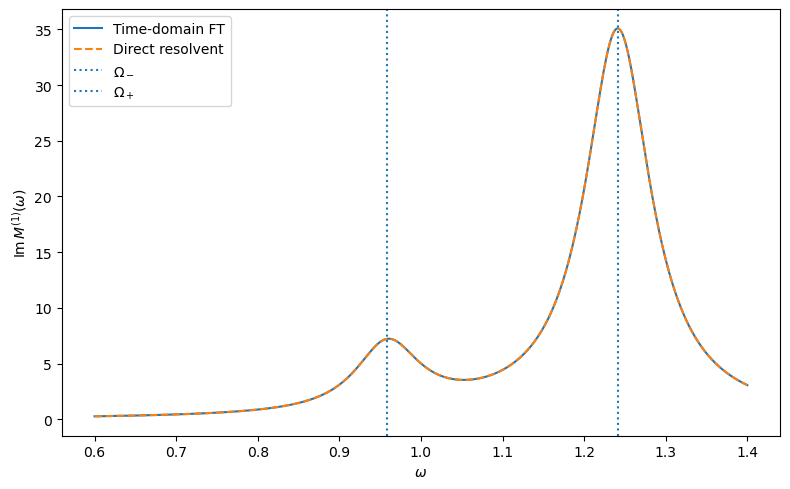

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.imag(M1_td),
    label="Time-domain FT"
)

plt.plot(
    omega_grid,
    np.imag(M1_fd),
    "--",
    label="Direct resolvent"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\mathrm{Im}\,M^{(1)}(\omega)$")
plt.legend()
plt.tight_layout()
plt.savefig(
    figures_dir / "linear_impulsive_td_vs_resolvent.pdf",
    bbox_inches="tight"
)
plt.show()

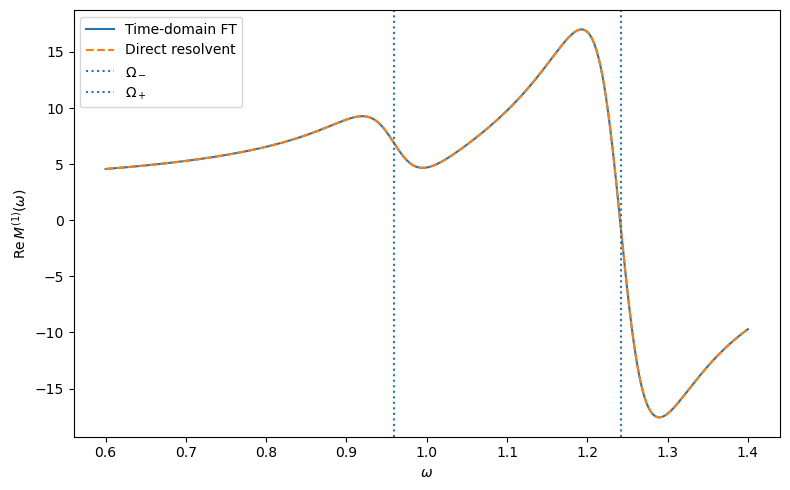

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.real(M1_td),
    label="Time-domain FT"
)

plt.plot(
    omega_grid,
    np.real(M1_fd),
    "--",
    label="Direct resolvent"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\mathrm{Re}\,M^{(1)}(\omega)$")
plt.legend()
plt.tight_layout()
plt.show()

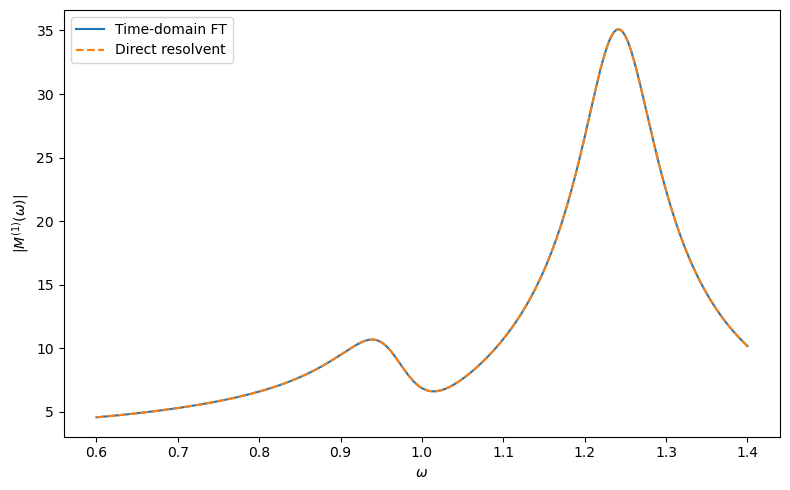

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.abs(M1_td),
    label="Time-domain FT"
)

plt.plot(
    omega_grid,
    np.abs(M1_fd),
    "--",
    label="Direct resolvent"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$|M^{(1)}(\omega)|$")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
rho_ss = stationary_state(
    L_super,
    model["d"]
)

print("rho_ss =")
print(np.round(rho_ss, 8))

print("\nTrace =", np.trace(rho_ss))

print(
    "Stationary-state residual =",
    norm(L_super @ vec(rho_ss))
)

rho_ss =
[[ 0.91115702+0.j -0.        -0.j  0.        +0.j  0.        +0.j]
 [-0.        +0.j  0.04338843+0.j -0.        +0.j -0.        +0.j]
 [ 0.        -0.j -0.        -0.j  0.04338843+0.j  0.        -0.j]
 [ 0.        +0.j -0.        -0.j  0.        +0.j  0.00206612+0.j]]

Trace = (1+0j)
Stationary-state residual = 1.7414670990977083e-18


## 5. Finite-pulse linear-response validation

We now include an explicit time-dependent laser field.

For this benchmark, the initial state is chosen to be the stationary
state of the field-free Liouvillian,

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle=0.
$$

This guarantees time-translation invariance of the unperturbed
response and allows the first-order polarization to be written as the
convolution

$$
P^{(1)}(t)
=
\int_{-\infty}^{+\infty}
dt'\,
R^{(1)}(t-t')E(t').
$$

With the Fourier convention

$$
f(\omega)
=
\int_{-\infty}^{+\infty}
dt\,
e^{i\omega t}f(t),
$$

the convolution theorem gives

$$
P^{(1)}(\omega)
=
E(\omega)M^{(1)}(\omega).
$$

We will compare this frequency-domain prediction with direct numerical
integration of the first-order driven master equation.

In [56]:
E0 = 1.0
omega_L = 1.10
sigma = 2.0
t_c = 12.0


def E_field(t):
    """
    Real Gaussian laser pulse.
    """
    u = t - t_c

    return (
        E0
        * np.exp(-u**2 / (2.0 * sigma**2))
        * np.cos(omega_L * u)
    )

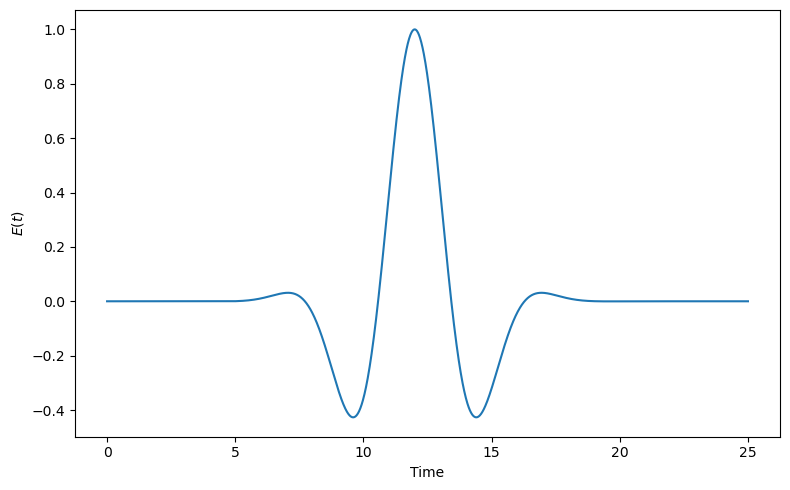

In [57]:
t_laser = np.linspace(
    0.0,
    25.0,
    2000
)

E_laser = E_field(t_laser)

plt.figure(figsize=(8, 5))

plt.plot(
    t_laser,
    E_laser
)

plt.xlabel("Time")
plt.ylabel(r"$E(t)$")
plt.tight_layout()
plt.show()

In [58]:
def linear_driven_rhs(t, rho1_vec):
    """
    First-order driven Lindblad equation.

    This implementation uses H_S and the jump operators directly,
    rather than L_super.
    """

    rho1 = unvec(rho1_vec, 4)

    # Field-free Lindblad evolution
    drho1 = (
        -1j / hbar
        * (H_S @ rho1 - rho1 @ H_S)
    )

    for L in jump_operators:
        drho1 += dissipator_rho(
            L,
            rho1
        )

    # First-order laser source
    source = (
        E_field(t)
        * 1j / hbar
        * (
            mu @ rho_ss
            - rho_ss @ mu
        )
    )

    drho1 += source

    return vec(drho1)

In [59]:
rho1_initial = np.zeros(
    (4, 4),
    dtype=complex
)

rho1_initial_vec = vec(
    rho1_initial
)

In [60]:
dt_pulse = 0.02
t_max_pulse = 200.0

times_pulse = np.arange(
    0.0,
    t_max_pulse + dt_pulse,
    dt_pulse
)

print(
    "Number of time points =",
    len(times_pulse)
)

Number of time points = 10001


In [61]:
solution_linear_pulse = solve_ivp(
    linear_driven_rhs,
    t_span=(
        0.0,
        t_max_pulse
    ),
    y0=rho1_initial_vec,
    t_eval=times_pulse,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

print(
    "Driven linear ODE successful:",
    solution_linear_pulse.success
)

print(
    "Message:",
    solution_linear_pulse.message
)

Driven linear ODE successful: True
Message: The solver successfully reached the end of the integration interval.


In [62]:
rho1_pulse_ode = (
    solution_linear_pulse.y.T
)

print(
    "Trajectory shape:",
    rho1_pulse_ode.shape
)

Trajectory shape: (10001, 16)


In [63]:
P1_pulse_ode = np.array([
    mu_bra @ rho_vec
    for rho_vec in rho1_pulse_ode
])

In [64]:
print(
    "Largest imaginary part of P1(t) =",
    np.max(
        np.abs(
            np.imag(P1_pulse_ode)
        )
    )
)

Largest imaginary part of P1(t) = 4.440892098500626e-16


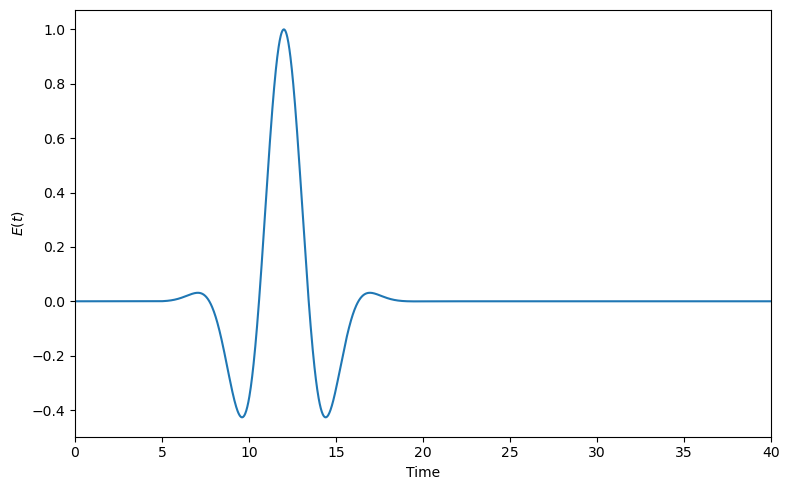

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    times_pulse,
    E_field(times_pulse)
)

plt.xlim(0, 40)

plt.xlabel("Time")
plt.ylabel(r"$E(t)$")
plt.tight_layout()
plt.show()

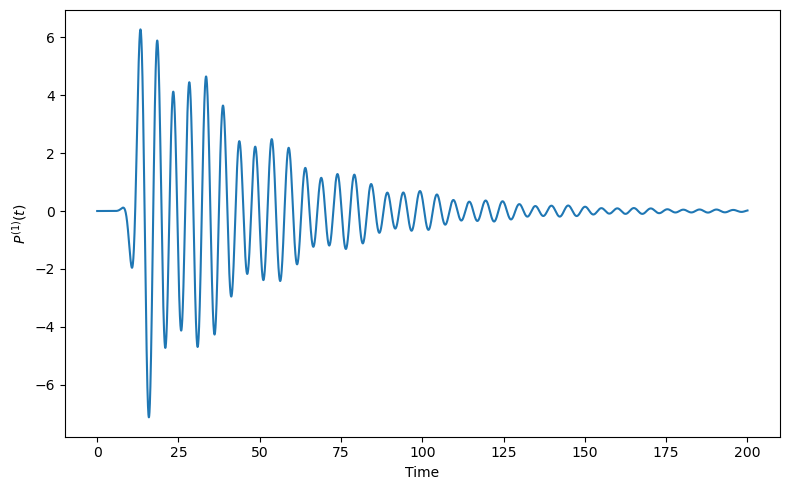

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    times_pulse,
    np.real(P1_pulse_ode)
)

plt.xlabel("Time")
plt.ylabel(r"$P^{(1)}(t)$")
plt.tight_layout()
plt.show()

### 5.1 Gaussian laser spectrum

For the real Gaussian pulse

$$
E(t)
=
E_0
\exp\left[
-\frac{(t-t_c)^2}{2\sigma^2}
\right]
\cos\left[
\omega_L(t-t_c)
\right],
$$

the Fourier transform under the convention

$$
E(\omega)
=
\int_{-\infty}^{+\infty}
dt\,
e^{i\omega t}E(t)
$$

is

$$
E(\omega)
=
\frac{E_0}{2}
\sqrt{2\pi}\sigma\,
e^{i\omega t_c}
\left[
\exp\left(
-\frac{\sigma^2}{2}
(\omega-\omega_L)^2
\right)
+
\exp\left(
-\frac{\sigma^2}{2}
(\omega+\omega_L)^2
\right)
\right].
$$

The factor $e^{i\omega t_c}$ represents the spectral phase associated
with shifting the pulse center from the time origin to $t_c$.

In [67]:
omega_grid = np.linspace(
    0.6,
    1.4,
    801
)

In [68]:
def E_spectrum(omega):
    """
    Analytical Fourier transform of the real Gaussian pulse.
    """

    positive_branch = np.exp(
        -0.5 * sigma**2 * (omega - omega_L)**2
    )

    negative_branch = np.exp(
        -0.5 * sigma**2 * (omega + omega_L)**2
    )

    phase = np.exp(
        1j * omega * t_c
    )

    return (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
        * phase
        * (
            positive_branch
            + negative_branch
        )
    )

In [69]:
E_omega_analytic = E_spectrum(
    omega_grid
)

In [70]:
E_time = E_field(times_pulse)

In [71]:
E_omega_numeric = []

for omega in omega_grid:

    integrand = (
        np.exp(1j * omega * times_pulse)
        * E_time
    )

    E_omega_numeric.append(
        np.trapezoid(
            integrand,
            times_pulse
        )
    )

E_omega_numeric = np.array(
    E_omega_numeric
)

In [72]:
E_omega_numeric = []

for omega in omega_grid:

    integrand = (
        np.exp(1j * omega * times_pulse)
        * E_time
    )

    E_omega_numeric.append(
        np.trapezoid(
            integrand,
            times_pulse
        )
    )

E_omega_numeric = np.array(
    E_omega_numeric
)

In [73]:
laser_spectrum_error = (
    norm(
        E_omega_numeric
        - E_omega_analytic
    )
    /
    norm(E_omega_analytic)
)

print(
    "Laser-spectrum relative L2 error =",
    laser_spectrum_error
)

Laser-spectrum relative L2 error = 1.1910050651136561e-09


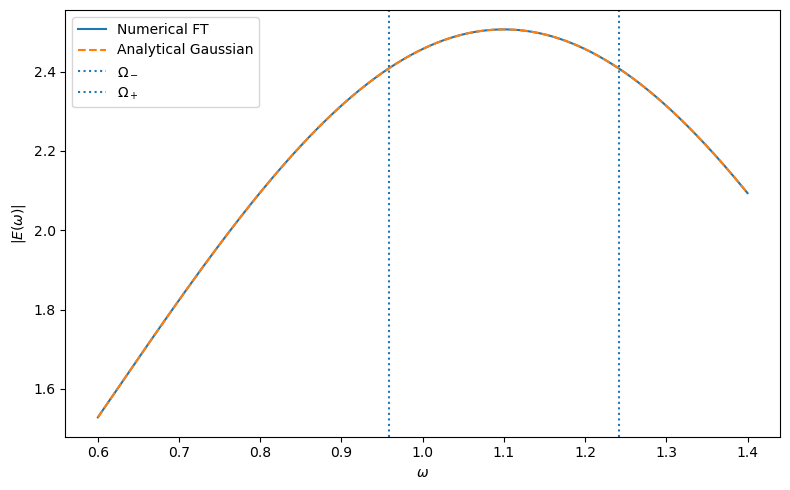

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.abs(E_omega_numeric),
    label="Numerical FT"
)

plt.plot(
    omega_grid,
    np.abs(E_omega_analytic),
    "--",
    label="Analytical Gaussian"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$|E(\omega)|$")
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
rho_ss_vec = vec(
    rho_ss
)

rho1_ss_source = (
    V @ rho_ss_vec
)

In [76]:
M1_ss_fd = []

for omega in omega_grid:

    A = (
        -1j * omega * I16
        - L_super
    )

    x = np.linalg.solve(
        A,
        rho1_ss_source
    )

    M1_ss_fd.append(
        mu_bra @ x
    )

M1_ss_fd = np.array(
    M1_ss_fd
)

In [77]:
P1_fd = (
    E_omega_analytic
    * M1_ss_fd
)

In [78]:
P1_ode_omega = []

for omega in omega_grid:

    integrand = (
        np.exp(
            1j * omega * times_pulse
        )
        * P1_pulse_ode
    )

    P1_ode_omega.append(
        np.trapezoid(
            integrand,
            times_pulse
        )
    )

P1_ode_omega = np.array(
    P1_ode_omega
)

In [79]:
idx_test = np.argmin(
    np.abs(
        omega_grid
        - omega_plus
    )
)

print(
    "omega_test =",
    omega_grid[idx_test]
)

print(
    "Driven ODE =",
    P1_ode_omega[idx_test]
)

print(
    "E(omega) M(omega) =",
    P1_fd[idx_test]
)

omega_test = 1.241
Driven ODE = (-90.4345488702246-86.59023367167353j)
E(omega) M(omega) = (-90.86503751016191-86.96596369058207j)


In [80]:
point_error = abs(
    P1_ode_omega[idx_test]
    - P1_fd[idx_test]
)

point_relative_error = (
    point_error
    /
    abs(P1_fd[idx_test])
)

print(
    "Point relative error =",
    point_relative_error
)

Point relative error = 0.0045429759640833916


In [81]:
finite_pulse_relative_L2_error = (
    norm(
        P1_ode_omega
        - P1_fd
    )
    /
    norm(P1_fd)
)

print(
    "Finite-pulse complex-spectrum relative L2 error =",
    finite_pulse_relative_L2_error
)

Finite-pulse complex-spectrum relative L2 error = 0.004530742715131934


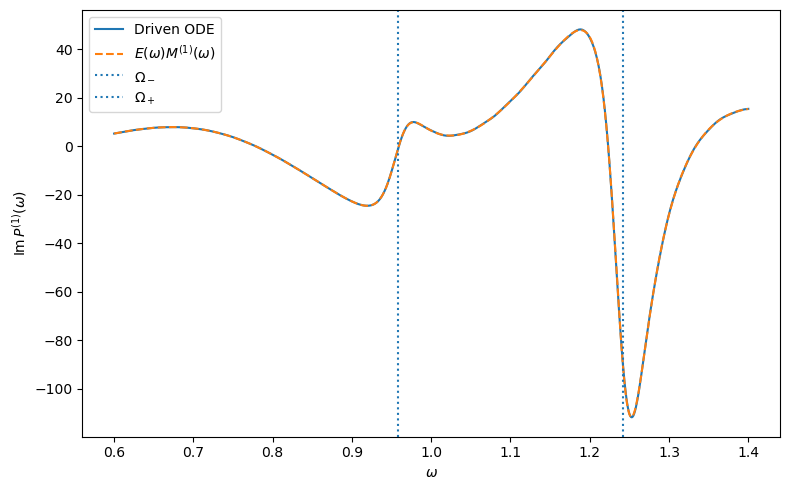

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.imag(P1_ode_omega),
    label="Driven ODE"
)

plt.plot(
    omega_grid,
    np.imag(P1_fd),
    "--",
    label=r"$E(\omega)M^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$\mathrm{Im}\,P^{(1)}(\omega)$"
)

plt.legend()
plt.tight_layout()
plt.show()

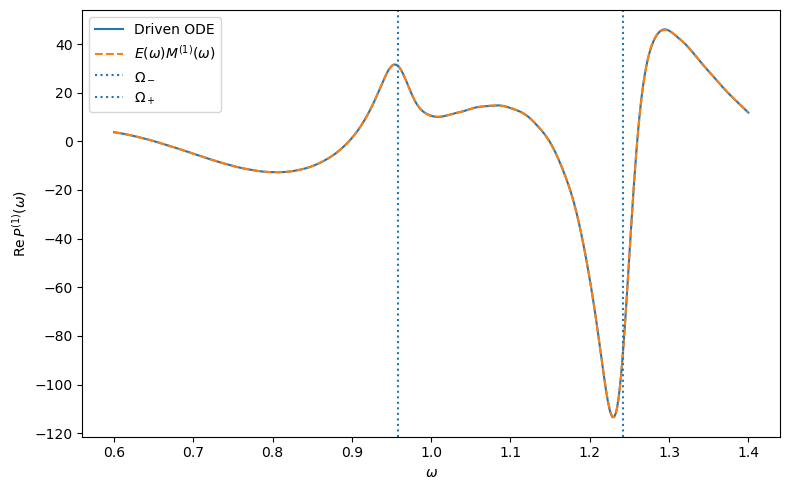

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.real(P1_ode_omega),
    label="Driven ODE"
)

plt.plot(
    omega_grid,
    np.real(P1_fd),
    "--",
    label=r"$E(\omega)M^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$\mathrm{Re}\,P^{(1)}(\omega)$"
)

plt.legend()
plt.tight_layout()
plt.show()

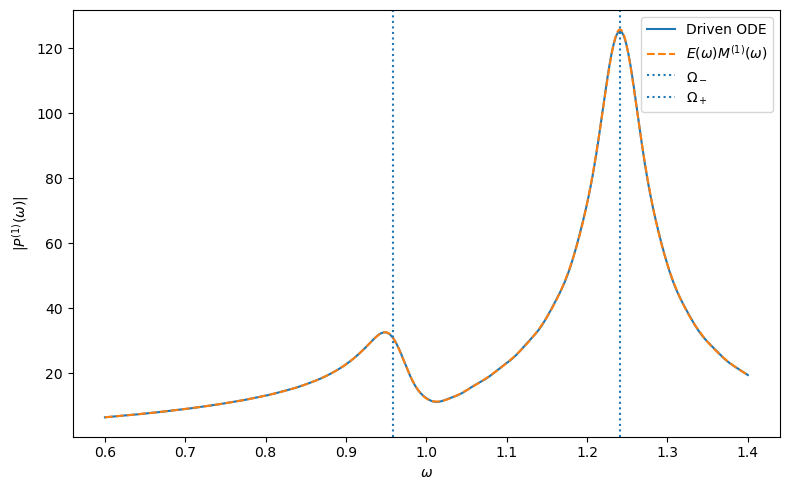

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.abs(P1_ode_omega),
    label="Driven ODE"
)

plt.plot(
    omega_grid,
    np.abs(P1_fd),
    "--",
    label=r"$E(\omega)M^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$|P^{(1)}(\omega)|$"
)

plt.legend()
plt.tight_layout()
plt.savefig(
    figures_dir / "linear_stationary_finite_pulse.pdf",
    bbox_inches="tight"
)
plt.show()

In [85]:
def E_plus_field(t):
    """
    Positive-frequency component of the Gaussian laser pulse.
    """
    u = t - t_c

    return (
        0.5
        * E0
        * np.exp(-u**2 / (2.0 * sigma**2))
        * np.exp(-1j * omega_L * u)
    )


def E_plus_spectrum(omega):
    """
    Analytical Fourier transform of E_plus_field
    under the convention exp(+i omega t).
    """
    return (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
        * np.exp(1j * omega * t_c)
        * np.exp(
            -0.5
            * sigma**2
            * (omega - omega_L)**2
        )
    )

In [86]:
E_plus_omega = E_plus_spectrum(omega_grid)

In [87]:
P1_plus_fd = (
    E_plus_omega
    * M1_ss_fd
)

In [88]:
def linear_driven_plus_rhs(t, rho1_vec):
    """
    First-order Lindblad equation driven only by
    the positive-frequency component E_plus(t).
    """

    rho1 = unvec(rho1_vec, 4)

    # Field-free evolution
    drho1 = (
        -1j / hbar
        * (H_S @ rho1 - rho1 @ H_S)
    )

    for L in jump_operators:
        drho1 += dissipator_rho(
            L,
            rho1
        )

    # Positive-frequency laser source
    source = (
        E_plus_field(t)
        * 1j / hbar
        * (
            mu @ rho_ss
            - rho_ss @ mu
        )
    )

    drho1 += source

    return vec(drho1)

In [89]:
solution_linear_plus = solve_ivp(
    linear_driven_plus_rhs,
    t_span=(0.0, t_max_pulse),
    y0=rho1_initial_vec,
    t_eval=times_pulse,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

print(
    "Positive-frequency ODE successful:",
    solution_linear_plus.success
)

Positive-frequency ODE successful: True


In [90]:
rho1_plus_ode = (
    solution_linear_plus.y.T
)

P1_plus_ode_t = np.array([
    mu_bra @ rho_vec
    for rho_vec in rho1_plus_ode
])

In [91]:
P1_plus_ode_omega = []

for omega in omega_grid:

    integrand = (
        np.exp(
            1j * omega * times_pulse
        )
        * P1_plus_ode_t
    )

    P1_plus_ode_omega.append(
        np.trapezoid(
            integrand,
            times_pulse
        )
    )

P1_plus_ode_omega = np.array(
    P1_plus_ode_omega
)

In [92]:
plus_relative_L2_error = (
    norm(
        P1_plus_ode_omega
        - P1_plus_fd
    )
    /
    norm(P1_plus_fd)
)

print(
    "Positive-frequency relative L2 error =",
    plus_relative_L2_error
)

Positive-frequency relative L2 error = 0.0044962390515529095


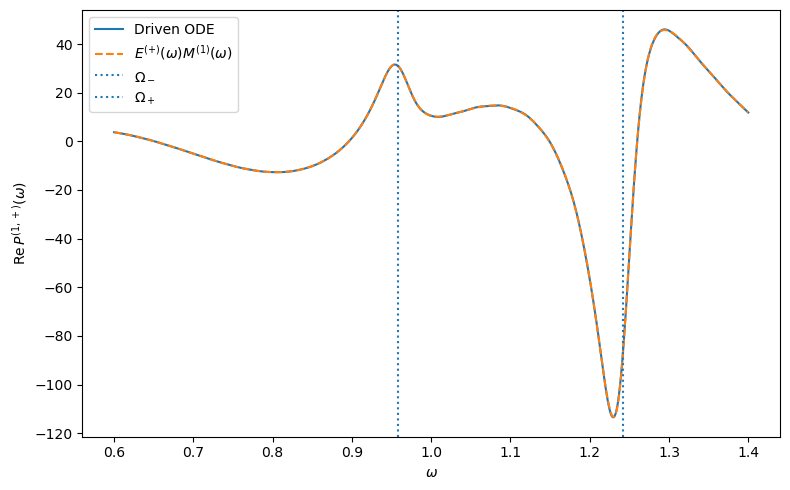

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.real(P1_plus_ode_omega),
    label="Driven ODE"
)

plt.plot(
    omega_grid,
    np.real(P1_plus_fd),
    "--",
    label=r"$E^{(+)}(\omega)M^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$\mathrm{Re}\,P^{(1,+)}(\omega)$"
)

plt.legend()
plt.tight_layout()
plt.show()

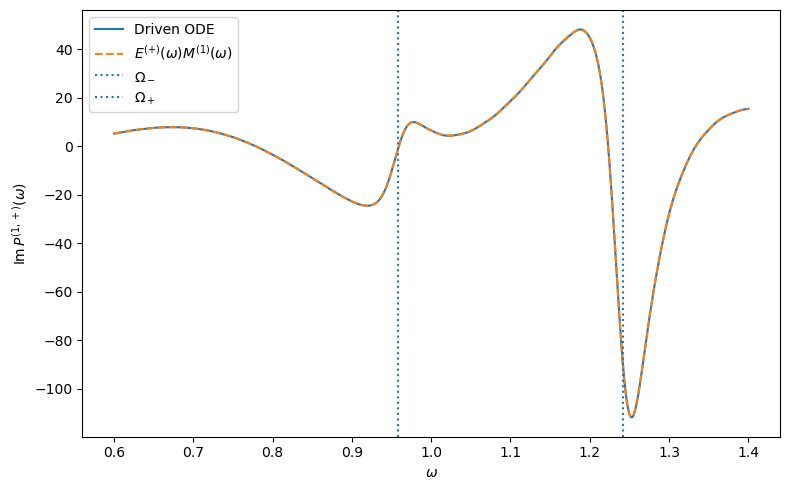

In [94]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.imag(P1_plus_ode_omega),
    label="Driven ODE"
)

plt.plot(
    omega_grid,
    np.imag(P1_plus_fd),
    "--",
    label=r"$E^{(+)}(\omega)M^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$\mathrm{Im}\,P^{(1,+)}(\omega)$"
)

plt.legend()
plt.tight_layout()
plt.show()

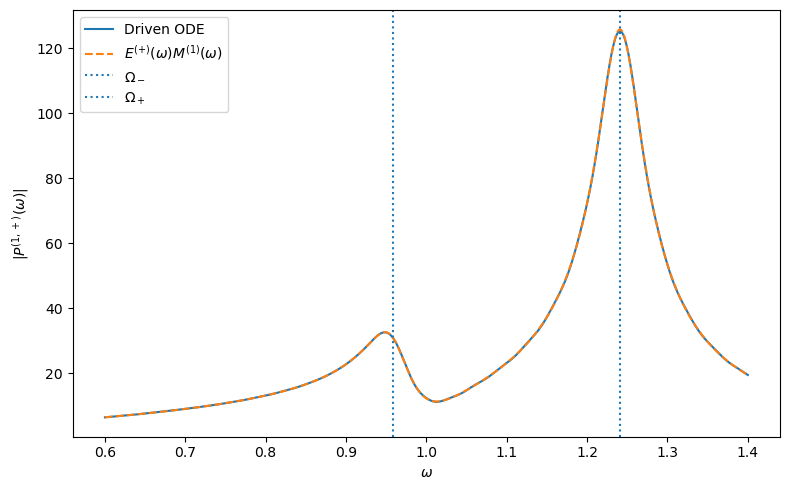

In [95]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.abs(P1_plus_ode_omega),
    label="Driven ODE"
)

plt.plot(
    omega_grid,
    np.abs(P1_plus_fd),
    "--",
    label=r"$E^{(+)}(\omega)M^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(
    r"$|P^{(1,+)}(\omega)|$"
)

plt.legend()
plt.tight_layout()
plt.show()

In [96]:
mask = np.abs(E_plus_omega) > 1e-8

M1_recovered = (
    P1_plus_ode_omega[mask]
    / E_plus_omega[mask]
)

M1_reference = M1_ss_fd[mask]

recovery_error = (
    norm(M1_recovered - M1_reference)
    / norm(M1_reference)
)

print(
    "Recovered molecular-response relative L2 error =",
    recovery_error
)

Recovered molecular-response relative L2 error = 0.004464918199066123


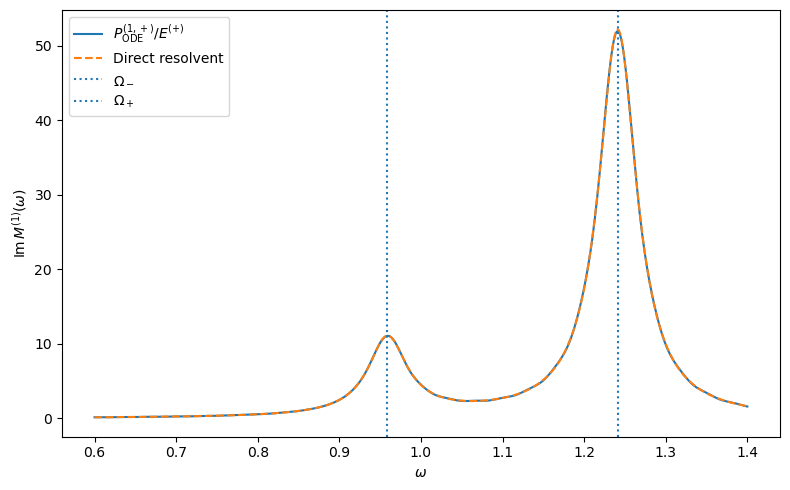

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid[mask],
    np.imag(M1_recovered),
    label=r"$P^{(1,+)}_{\mathrm{ODE}}/E^{(+)}$"
)

plt.plot(
    omega_grid[mask],
    np.imag(M1_reference),
    "--",
    label="Direct resolvent"
)

plt.axvline(
    omega_minus,
    linestyle=":",
    label=r"$\Omega_-$"
)

plt.axvline(
    omega_plus,
    linestyle=":",
    label=r"$\Omega_+$"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\mathrm{Im}\,M^{(1)}(\omega)$")
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
def E_minus_spectrum(omega):

    return (
        0.5
        * E0
        * np.sqrt(2.0 * np.pi)
        * sigma
        * np.exp(1j * omega * t_c)
        * np.exp(
            -0.5
            * sigma**2
            * (omega + omega_L)**2
        )
    )


E_minus_omega = E_minus_spectrum(
    omega_grid
)

P1_minus_fd = (
    E_minus_omega
    * M1_ss_fd
)

In [99]:
P1_reconstructed = (
    P1_plus_fd
    + P1_minus_fd
)

print(
    "Full-field reconstruction error =",
    norm(P1_fd - P1_reconstructed)
    / norm(P1_fd)
)

print(
    "Negative-branch fraction in positive-frequency window =",
    norm(P1_minus_fd)
    / norm(P1_fd)
)

Full-field reconstruction error = 1.1609641802737872e-16
Negative-branch fraction in positive-frequency window = 0.00027451878005820273


### 5.2 Relation between measured polarization and molecular response

For a stationary initial state,

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle=0,
$$

the linear polarization satisfies

$$
P^{(1)}(\omega)
=
E(\omega)M^{(1)}(\omega).
$$

Therefore, if the complex polarization and the complex laser spectrum
are both known, the molecular response can in principle be recovered as

$$
\boxed{
M^{(1)}(\omega)
=
\frac{
P^{(1)}(\omega)
}{
E(\omega)
}.
}
$$

This division is meaningful only over the frequency region where
$E(\omega)$ is appreciably nonzero.  If the laser spectrum becomes very
small, division by $E(\omega)$ amplifies numerical or experimental
noise.

For the positive-frequency component of a Gaussian pulse,

$$
E^{(+)}(t)
=
\frac{E_0}{2}
\exp\left[
-\frac{(t-t_c)^2}{2\sigma^2}
\right]
\exp\left[
-i\omega_L(t-t_c)
\right],
$$

the corresponding spectrum is

$$
E^{(+)}(\omega)
=
\frac{E_0}{2}
\sqrt{2\pi}\sigma\,
e^{i\omega t_c}
\exp\left[
-\frac{\sigma^2}{2}
(\omega-\omega_L)^2
\right].
$$

As the pulse duration becomes very short,

$$
\sigma\rightarrow0,
$$

the Gaussian spectral envelope becomes approximately flat over any
finite frequency window,

$$
\exp\left[
-\frac{\sigma^2}{2}
(\omega-\omega_L)^2
\right]
\rightarrow1.
$$

Thus,

$$
P^{(1,+)}(\omega)
\approx
C\,e^{i\omega t_c}
M^{(1)}(\omega),
$$

where

$$
C
=
\frac{E_0}{2}\sqrt{2\pi}\sigma.
$$

If the pulse center defines the time origin, $t_c=0$, the spectral phase
disappears and

$$
P^{(1,+)}(\omega)
\approx
C\,M^{(1)}(\omega).
$$

Therefore, in the impulsive limit, the measured polarization has the
same spectral shape as the molecular response, up to an overall
constant factor.

A proper delta-pulse limit requires the pulse area to remain finite as
$\sigma\rightarrow0$.  If $E_0$ is held fixed, then

$$
C\propto\sigma\rightarrow0,
$$

and the pulse strength vanishes.  Instead, one may scale

$$
E_0\propto\frac{1}{\sigma},
$$

so that the pulse approaches

$$
E(t)\rightarrow A\,\delta(t),
$$

with

$$
E(\omega)\rightarrow A.
$$

The corresponding polarization then becomes

$$
\boxed{
P^{(1)}(\omega)
\rightarrow
A\,M^{(1)}(\omega).
}
$$

For a unit-area impulsive pulse, $A=1$, this reduces to

$$
P^{(1)}(\omega)
=
M^{(1)}(\omega).
$$

## 6. Weak-field limit of the full driven master equation

The previous finite-pulse calculation propagated the first-order
perturbative equation

$$
\frac{d\rho^{(1)}}{dt}
=
\mathcal{L}\rho^{(1)}
+
E(t)V\rho_{\mathrm{ss}}.
$$

We now compare this result with the complete laser-driven master
equation,

$$
\frac{d\rho}{dt}
=
-\frac{i}{\hbar}
[H_S-\mu E(t),\rho]
+
\sum_k
\mathcal{D}[L_k]\rho.
$$

Equivalently, in Liouville space,

$$
\frac{d}{dt}
|\rho(t)\rangle\rangle
=
\left[
\mathcal{L}
+
E(t)V
\right]
|\rho(t)\rangle\rangle.
$$

For a weak field of amplitude $\epsilon$,

$$
E_\epsilon(t)
=
\epsilon E(t),
$$

the induced polarization should satisfy

$$
\Delta P_{\mathrm{full}}(t)
=
P_{\mathrm{full}}(t)
-
P_{\mathrm{free}}(t)
\approx
\epsilon P^{(1)}(t).
$$

Agreement in the limit $\epsilon\rightarrow0$ verifies that the
perturbative linear-response equation is recovered from the complete
driven dynamics.

In [100]:
def full_driven_rhs(t, rho_vec, epsilon):
    """
    Complete laser-driven Lindblad master equation.
    """

    rho = unvec(rho_vec, 4)

    # Scaled physical laser field
    E_t = epsilon * E_field(t)

    # Complete Hamiltonian including the laser interaction
    H_total = H_S - mu * E_t

    drho = (
        -1j / hbar
        * (
            H_total @ rho
            - rho @ H_total
        )
    )

    for L in jump_operators:
        drho += dissipator_rho(
            L,
            rho
        )

    return vec(drho)

In [101]:
epsilon = 0.01

In [102]:
solution_full = solve_ivp(
    lambda t, y: full_driven_rhs(
        t,
        y,
        epsilon
    ),
    t_span=(
        0.0,
        t_max_pulse
    ),
    y0=vec(rho_ss),
    t_eval=times_pulse,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

print(
    "Full driven ODE successful:",
    solution_full.success
)

Full driven ODE successful: True


In [103]:
rho_full = solution_full.y.T

P_full_t = np.array([
    mu_bra @ rho_vec
    for rho_vec in rho_full
])

In [104]:
P_background = (
    mu_bra @ vec(rho_ss)
)

print(
    "Stationary polarization =",
    P_background
)

Stationary polarization = (1.401408211446379e-18+0j)


In [105]:
delta_P_full_t = (
    P_full_t
    - P_background
)

In [106]:
P_linear_prediction_t = (
    epsilon
    * P1_pulse_ode
)

In [107]:
weak_field_relative_error = (
    norm(
        delta_P_full_t
        - P_linear_prediction_t
    )
    /
    norm(P_linear_prediction_t)
)

print(
    "Weak-field relative error =",
    weak_field_relative_error
)

Weak-field relative error = 0.0007447186947557293


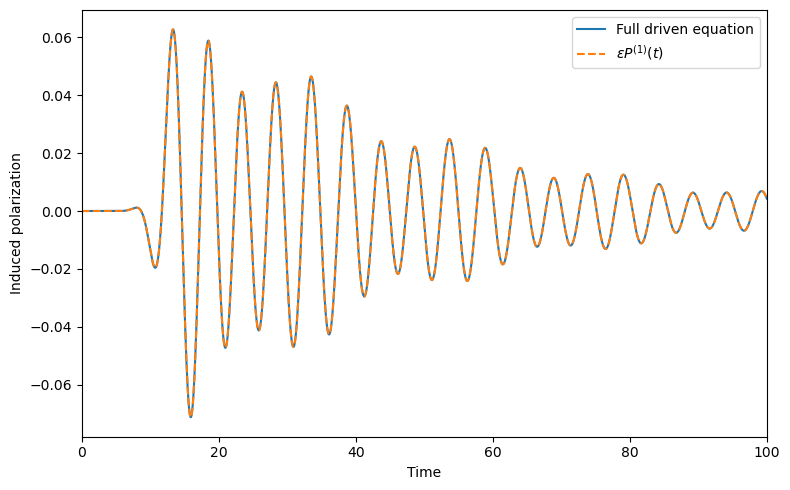

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(
    times_pulse,
    np.real(delta_P_full_t),
    label="Full driven equation"
)

plt.plot(
    times_pulse,
    np.real(P_linear_prediction_t),
    "--",
    label=r"$\epsilon P^{(1)}(t)$"
)

plt.xlim(0, 100)

plt.xlabel("Time")
plt.ylabel("Induced polarization")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Prepared nonstationary initial state

We now return to the prepared ground state

$$
\rho_0=|gg\rangle\langle gg|.
$$

At finite bath temperature this state is not stationary,

$$
\mathcal{L}|\rho_0\rangle\rangle\neq0.
$$

Consequently, if the first laser pulse has a finite duration, the
zeroth-order state can evolve under the field-free Liouvillian while
the pulse is arriving,

$$
|\rho^{(0)}(t)\rangle\rangle
=
e^{\mathcal{L}t}
|\rho_0\rangle\rangle.
$$

The exact first-order equation is therefore

$$
\frac{d}{dt}|\rho^{(1)}(t)\rangle\rangle
=
\mathcal{L}|\rho^{(1)}(t)\rangle\rangle
+
E^{(+)}(t)
V
e^{\mathcal{L}t}
|\rho_0\rangle\rangle.
$$

If the field-free evolution of the prepared state is negligible over
the duration of the first pulse, one may instead use the frozen-state
approximation

$$
e^{\mathcal{L}t}|\rho_0\rangle\rangle
\simeq
|\rho_0\rangle\rangle,
$$

which gives

$$
\frac{d}{dt}|\rho_{\mathrm{frozen}}^{(1)}(t)\rangle\rangle
=
\mathcal{L}|\rho_{\mathrm{frozen}}^{(1)}(t)\rangle\rangle
+
E^{(+)}(t)V|\rho_0\rangle\rangle.
$$

The corresponding frequency-domain factorization is

$$
P_{\mathrm{frozen}}^{(1,+)}(\omega)
=
E^{(+)}(\omega)
M_{\rho_0}^{(1)}(\omega),
$$

with

$$
M_{\rho_0}^{(1)}(\omega)
=
\langle\!\langle\mu|
G(\omega)V
|\rho_0\rangle\rangle.
$$

We will compare the exact prepared-state dynamics with this
frozen-state approximation as the pulse width is varied.

In [109]:
rho0_vec = vec(rho0)

kappa0 = (
    norm(L_super @ rho0_vec)
    / norm(rho0_vec)
)

print("Initial-state drift rate kappa0 =", kappa0)
print("Associated timescale 1/kappa0   =", 1.0 / kappa0)

Initial-state drift rate kappa0 = 0.006123724356957946
Associated timescale 1/kappa0   = 163.29931618554517


In [110]:
sigma_prepared = 2.0
t_c_prepared = 4.0 * sigma_prepared
omega_L_prepared = 1.10
E0_prepared = 1.0

In [111]:
def E_plus_prepared(t):
    u = t - t_c_prepared

    return (
        0.5
        * E0_prepared
        * np.exp(
            -u**2 / (2.0 * sigma_prepared**2)
        )
        * np.exp(
            -1j * omega_L_prepared * u
        )
    )

In [112]:
chi_prepared = (
    sigma_prepared * kappa0
)

print("sigma =", sigma_prepared)
print("chi = sigma * kappa0 =", chi_prepared)

sigma = 2.0
chi = sigma * kappa0 = 0.012247448713915893


In [113]:
def prepared_exact_rhs(t, y):
    """
    Exact first-order dynamics for a nonstationary prepared state.

    y contains:
        first 16 elements  -> rho^(0)
        second 16 elements -> rho^(1)
    """

    rho0_t_vec = y[:16]
    rho1_t_vec = y[16:]

    rho0_t = unvec(rho0_t_vec, 4)
    rho1_t = unvec(rho1_t_vec, 4)

    # Zeroth-order field-free dynamics
    drho0 = (
        -1j / hbar
        * (H_S @ rho0_t - rho0_t @ H_S)
    )

    for L in jump_operators:
        drho0 += dissipator_rho(
            L,
            rho0_t
        )

    # First-order field-free dynamics
    drho1 = (
        -1j / hbar
        * (H_S @ rho1_t - rho1_t @ H_S)
    )

    for L in jump_operators:
        drho1 += dissipator_rho(
            L,
            rho1_t
        )

    # Exact source acts on the evolving zeroth-order state
    source = (
        E_plus_prepared(t)
        * 1j / hbar
        * (
            mu @ rho0_t
            - rho0_t @ mu
        )
    )

    drho1 += source

    return np.concatenate([
        vec(drho0),
        vec(drho1),
    ])

In [114]:
rho1_zero_vec = np.zeros(
    16,
    dtype=complex
)

y0_prepared = np.concatenate([
    rho0_vec,
    rho1_zero_vec,
])

In [115]:
dt_prepared = 0.02
t_max_prepared = 200.0

times_prepared = np.arange(
    0.0,
    t_max_prepared + dt_prepared,
    dt_prepared
)

In [116]:
solution_prepared_exact = solve_ivp(
    prepared_exact_rhs,
    t_span=(0.0, t_max_prepared),
    y0=y0_prepared,
    t_eval=times_prepared,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

print(
    "Exact prepared-state ODE successful:",
    solution_prepared_exact.success
)

Exact prepared-state ODE successful: True


In [117]:
prepared_exact = (
    solution_prepared_exact.y.T
)

rho0_exact_t = (
    prepared_exact[:, :16]
)

rho1_exact_t = (
    prepared_exact[:, 16:]
)

In [118]:
P1_prepared_exact_t = (
    rho1_exact_t @ mu_bra
)

In [119]:
def prepared_frozen_rhs(t, rho1_vec):
    """
    First-order dynamics assuming the prepared rho0
    remains frozen during the first pulse.
    """

    rho1 = unvec(rho1_vec, 4)

    drho1 = (
        -1j / hbar
        * (H_S @ rho1 - rho1 @ H_S)
    )

    for L in jump_operators:
        drho1 += dissipator_rho(
            L,
            rho1
        )

    source = (
        E_plus_prepared(t)
        * 1j / hbar
        * (
            mu @ rho0
            - rho0 @ mu
        )
    )

    drho1 += source

    return vec(drho1)

In [120]:
solution_prepared_frozen = solve_ivp(
    prepared_frozen_rhs,
    t_span=(0.0, t_max_prepared),
    y0=rho1_zero_vec,
    t_eval=times_prepared,
    method="DOP853",
    rtol=1e-10,
    atol=1e-12,
)

rho1_frozen_t = (
    solution_prepared_frozen.y.T
)

P1_prepared_frozen_t = (
    rho1_frozen_t @ mu_bra
)

In [121]:
prepared_time_error = (
    norm(
        P1_prepared_exact_t
        - P1_prepared_frozen_t
    )
    /
    norm(P1_prepared_exact_t)
)

print(
    "Prepared-state time-domain relative L2 error =",
    prepared_time_error
)

Prepared-state time-domain relative L2 error = 0.044501814343569805


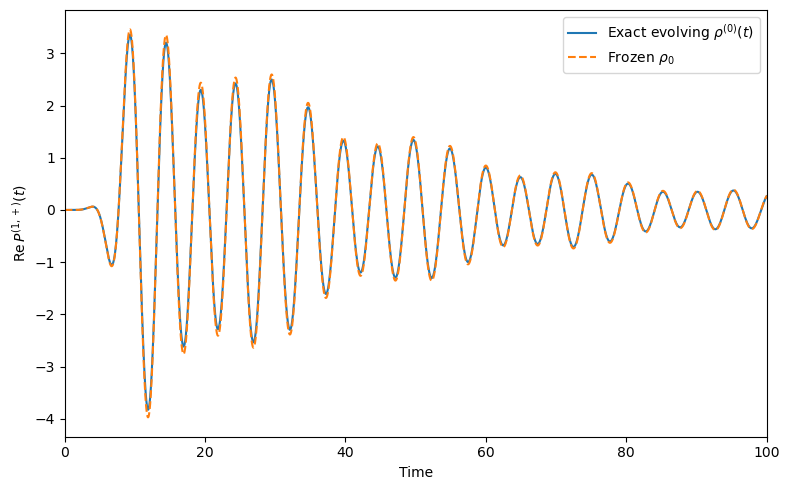

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(
    times_prepared,
    np.real(P1_prepared_exact_t),
    label="Exact evolving $\\rho^{(0)}(t)$"
)

plt.plot(
    times_prepared,
    np.real(P1_prepared_frozen_t),
    "--",
    label="Frozen $\\rho_0$"
)

plt.xlim(0, 100)

plt.xlabel("Time")
plt.ylabel(
    r"$\mathrm{Re}\,P^{(1,+)}(t)$"
)

plt.legend()
plt.tight_layout()
plt.show()

In [123]:
P1_prepared_exact_omega = []
P1_prepared_frozen_omega = []

for omega in omega_grid:

    phase = np.exp(
        1j * omega * times_prepared
    )

    P1_prepared_exact_omega.append(
        np.trapezoid(
            phase * P1_prepared_exact_t,
            times_prepared
        )
    )

    P1_prepared_frozen_omega.append(
        np.trapezoid(
            phase * P1_prepared_frozen_t,
            times_prepared
        )
    )

P1_prepared_exact_omega = np.array(
    P1_prepared_exact_omega
)

P1_prepared_frozen_omega = np.array(
    P1_prepared_frozen_omega
)

In [124]:
prepared_spectrum_error = (
    norm(
        P1_prepared_exact_omega
        - P1_prepared_frozen_omega
    )
    /
    norm(P1_prepared_exact_omega)
)

print(
    "Prepared-state spectral relative L2 error =",
    prepared_spectrum_error
)

Prepared-state spectral relative L2 error = 0.044618716438146626


In [125]:
M1_rho0_fd = []

rho1_rho0_source = (
    V @ rho0_vec
)

for omega in omega_grid:

    A = (
        -1j * omega * I16
        - L_super
    )

    x = np.linalg.solve(
        A,
        rho1_rho0_source
    )

    M1_rho0_fd.append(
        mu_bra @ x
    )

M1_rho0_fd = np.array(
    M1_rho0_fd
)

In [126]:
def E_plus_prepared_spectrum(omega):

    return (
        0.5
        * E0_prepared
        * np.sqrt(2.0 * np.pi)
        * sigma_prepared
        * np.exp(
            1j * omega * t_c_prepared
        )
        * np.exp(
            -0.5
            * sigma_prepared**2
            * (
                omega
                - omega_L_prepared
            )**2
        )
    )

In [127]:
E_plus_prepared_omega = (
    E_plus_prepared_spectrum(
        omega_grid
    )
)

P1_prepared_fd = (
    E_plus_prepared_omega
    * M1_rho0_fd
)

In [128]:
frozen_vs_fd_error = (
    norm(
        P1_prepared_frozen_omega
        - P1_prepared_fd
    )
    /
    norm(P1_prepared_fd)
)

print(
    "Frozen ODE vs E(omega)M(omega) error =",
    frozen_vs_fd_error
)

Frozen ODE vs E(omega)M(omega) error = 0.004170769071710757


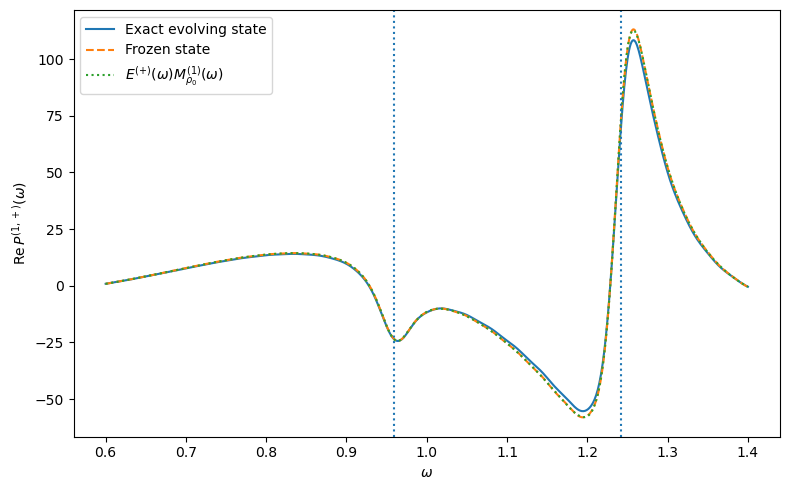

In [129]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.real(P1_prepared_exact_omega),
    label="Exact evolving state"
)

plt.plot(
    omega_grid,
    np.real(P1_prepared_frozen_omega),
    "--",
    label="Frozen state"
)

plt.plot(
    omega_grid,
    np.real(P1_prepared_fd),
    ":",
    label=r"$E^{(+)}(\omega)M_{\rho_0}^{(1)}(\omega)$"
)

plt.axvline(omega_minus, linestyle=":")
plt.axvline(omega_plus, linestyle=":")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\mathrm{Re}\,P^{(1,+)}(\omega)$")
plt.legend()
plt.tight_layout()
plt.show()

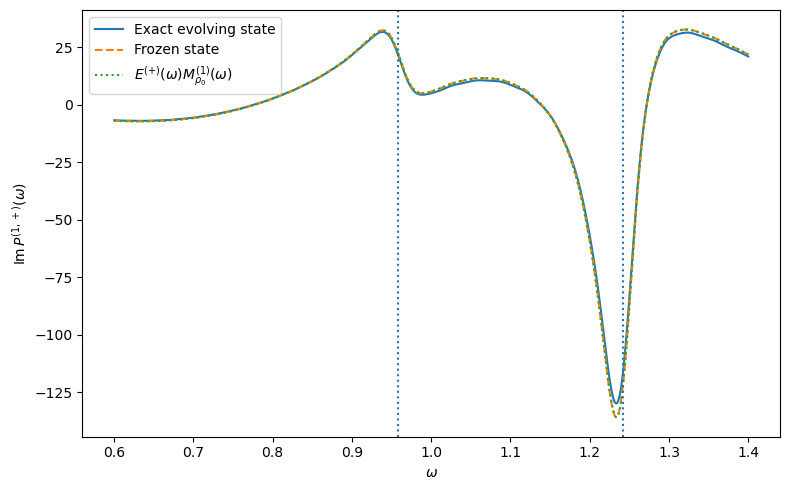

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.imag(P1_prepared_exact_omega),
    label="Exact evolving state"
)

plt.plot(
    omega_grid,
    np.imag(P1_prepared_frozen_omega),
    "--",
    label="Frozen state"
)

plt.plot(
    omega_grid,
    np.imag(P1_prepared_fd),
    ":",
    label=r"$E^{(+)}(\omega)M_{\rho_0}^{(1)}(\omega)$"
)

plt.axvline(omega_minus, linestyle=":")
plt.axvline(omega_plus, linestyle=":")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\mathrm{Im}\,P^{(1,+)}(\omega)$")
plt.legend()
plt.tight_layout()
plt.show()

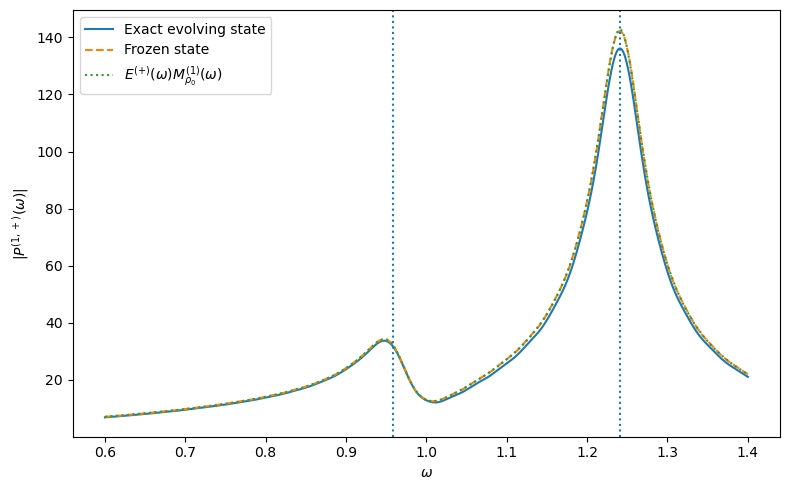

In [131]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.abs(P1_prepared_exact_omega),
    label="Exact evolving state"
)

plt.plot(
    omega_grid,
    np.abs(P1_prepared_frozen_omega),
    "--",
    label="Frozen state"
)

plt.plot(
    omega_grid,
    np.abs(P1_prepared_fd),
    ":",
    label=r"$E^{(+)}(\omega)M_{\rho_0}^{(1)}(\omega)$"
)

plt.axvline(omega_minus, linestyle=":")
plt.axvline(omega_plus, linestyle=":")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$|P^{(1,+)}(\omega)|$")
plt.legend()
plt.tight_layout()
plt.show()

In [132]:
rho0_exact_matrices = np.array([
    unvec(rho_vec, 4)
    for rho_vec in rho0_exact_t
])

pop_gg_exact = np.real(
    rho0_exact_matrices[:, 0, 0]
)

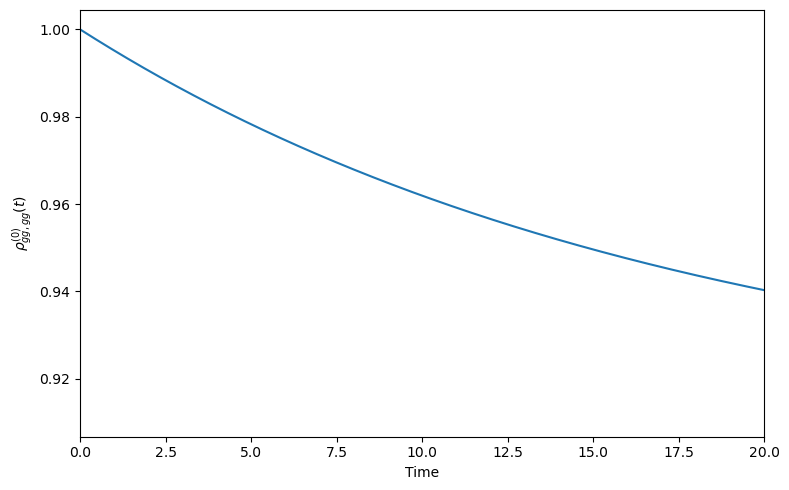

In [133]:
plt.figure(figsize=(8, 5))

plt.plot(
    times_prepared,
    pop_gg_exact
)

plt.xlim(0, 20)

plt.xlabel("Time")
plt.ylabel(r"$\rho_{gg,gg}^{(0)}(t)$")
plt.tight_layout()
plt.show()

In [134]:
mask_prepared = (
    np.abs(E_plus_prepared_omega)
    > 1e-6 * np.max(np.abs(E_plus_prepared_omega))
)

M1_effective_exact = (
    P1_prepared_exact_omega[mask_prepared]
    / E_plus_prepared_omega[mask_prepared]
)

M1_frozen_reference = (
    M1_rho0_fd[mask_prepared]
)

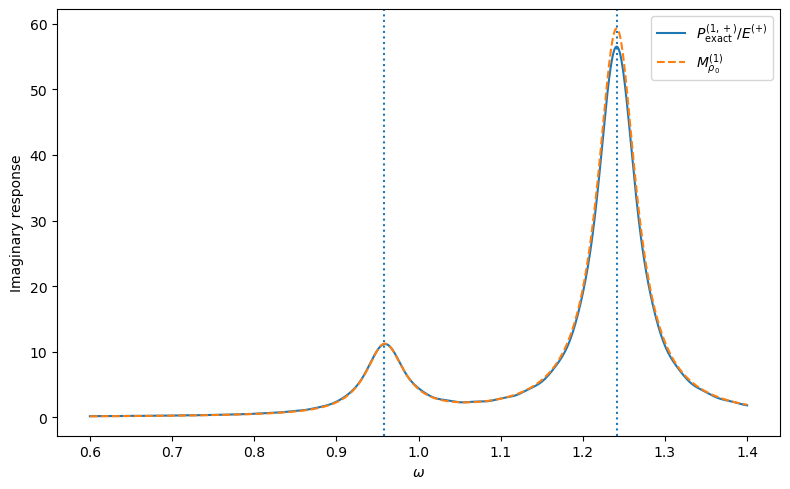

In [135]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid[mask_prepared],
    np.imag(M1_effective_exact),
    label=r"$P_{\rm exact}^{(1,+)}/E^{(+)}$"
)

plt.plot(
    omega_grid[mask_prepared],
    np.imag(M1_frozen_reference),
    "--",
    label=r"$M_{\rho_0}^{(1)}$"
)

plt.axvline(omega_minus, linestyle=":")
plt.axvline(omega_plus, linestyle=":")

plt.xlabel(r"$\omega$")
plt.ylabel("Imaginary response")
plt.legend()
plt.tight_layout()
plt.show()

### 7.1 Preparation delay versus pulse-width effects

The numerical results show that the nonstationarity of a prepared
initial state is controlled by two distinct timescales.

Define the initial drift rate

$$
\kappa_0
=
\frac{
\left\|
\mathcal{L}|\rho_0\rangle\rangle
\right\|
}{
\left\|
|\rho_0\rangle\rangle
\right\|
}.
$$

The parameter

$$
\chi_{\mathrm{width}}
=
\sigma\kappa_0
$$

estimates the field-free evolution of the prepared state over the
duration of the pulse, whereas

$$
\chi_{\mathrm{delay}}
=
t_c\kappa_0
$$

estimates the evolution accumulated between preparation at $t=0$ and
the center of the pulse at $t=t_c$.

For the present calculation,

$$
\kappa_0
=
0.0061237,
\qquad
\sigma=2,
\qquad
t_c=8,
$$

giving

$$
\chi_{\mathrm{width}}
\simeq
0.0122
$$

and

$$
\chi_{\mathrm{delay}}
\simeq
0.0490.
$$

The exact prepared-state calculation differs from the frozen-state
approximation by approximately $4.5\%$ in both the time and frequency
domains.  This error is therefore much more consistent with the
preparation-to-pulse delay scale $t_c\kappa_0$ than with the pulse-width
scale $\sigma\kappa_0$.

Thus, for a nonstationary prepared state, the frozen-state approximation
requires not only negligible evolution during the pulse but also
negligible evolution between preparation and the times at which the
pulse interacts appreciably with the system.  A useful pair of
conditions is therefore

$$
\boxed{
t_c\kappa_0\ll1,
\qquad
\sigma\kappa_0\ll1.
}
$$

More generally, the relevant condition is that

$$
e^{\mathcal{L}t}|\rho_0\rangle\rangle
\simeq
|\rho_0\rangle\rangle
$$

over the temporal region in which the laser field has appreciable
amplitude.

For the stationary preparation,

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle=0,
$$

so both effects vanish identically and the time-translation-invariant
convolution remains valid independently of the absolute pulse arrival
time.

## 8. Linear-response validation summary

The coupled thermal dimer implementation has now been validated at
several independent levels.

### 1. Liouville-space propagation

Direct integration of the Lindblad master equation agrees with
propagation generated by the Liouvillian superoperator,

$$
|\rho(t)\rangle\rangle
=
e^{\mathcal{L}t}
|\rho(0)\rangle\rangle.
$$

The maximum relative trajectory difference was of order

$$
10^{-11},
$$

confirming the vectorization convention and Liouvillian construction.

### 2. Impulsive linear response

The time-domain linear response,

$$
R^{(1)}(t)
=
\langle\!\langle\mu|
e^{\mathcal{L}t}
V
|\rho_0\rangle\rangle,
$$

agrees with the direct frequency-domain resolvent calculation,

$$
M^{(1)}(\omega)
=
\langle\!\langle\mu|
G(\omega)
V
|\rho_0\rangle\rangle.
$$

The complex-spectrum relative $L^2$ error was approximately

$$
1.2\times10^{-5}.
$$

This validates the direct resolvent formulation independently of the
finite-pulse treatment.

### 3. Finite Gaussian pulse for a stationary state

For the stationary preparation,

$$
\mathcal{L}|\rho_{\mathrm{ss}}\rangle\rangle=0,
$$

explicit first-order propagation under a Gaussian laser pulse agrees
with the frequency-domain factorization

$$
P^{(1)}(\omega)
=
E(\omega)M^{(1)}(\omega).
$$

The complex-spectrum relative difference was approximately

$$
4.5\times10^{-3}.
$$

The same agreement was obtained when the positive-frequency laser
component $E^{(+)}$ was propagated independently.

The decomposition

$$
P^{(1)}
=
P^{(1,+)}
+
P^{(1,-)}
$$

was also verified numerically.  In the positive-frequency spectral
window used here, the negative-frequency contribution is negligible.

### 4. Recovery of the molecular response

For the stationary preparation, division of the polarization by the
known laser spectrum recovers the molecular response,

$$
M^{(1)}(\omega)
=
\frac{
P^{(1)}(\omega)
}{
E(\omega)
},
$$

provided that the laser spectrum is appreciably nonzero.

This establishes the connection between the intrinsic molecular
response and the polarization produced by a finite experimental pulse.

### 5. Weak-field limit of the complete driven master equation

The perturbative first-order calculation was compared with the complete
laser-driven Lindblad equation,

$$
\frac{d\rho}{dt}
=
-\frac{i}{\hbar}
[H_S-\mu E(t),\rho]
+
\sum_k\mathcal{D}[L_k]\rho.
$$

For a weak field with scaling parameter

$$
\epsilon=0.01,
$$

the induced polarization from the complete equation agrees with

$$
\epsilon P^{(1)}(t)
$$

with a relative error of approximately

$$
7.4\times10^{-4}.
$$

Thus, the perturbative linear-response equation is correctly recovered
from the full nonlinear driven dynamics in the weak-field regime.

### 6. Nonstationary prepared ground state

At finite bath occupation, the prepared ground state

$$
\rho_0=|gg\rangle\langle gg|
$$

is not stationary,

$$
\mathcal{L}|\rho_0\rangle\rangle\neq0.
$$

Its initial drift rate was found to be

$$
\kappa_0
=
0.0061237,
$$

corresponding to a characteristic drift timescale

$$
\kappa_0^{-1}
\simeq
163.3.
$$

For the Gaussian pulse with

$$
\sigma=2,
\qquad
t_c=8,
$$

the dimensionless estimates are

$$
\chi_{\mathrm{width}}
=
\sigma\kappa_0
\simeq
0.0122,
$$

and

$$
\chi_{\mathrm{delay}}
=
t_c\kappa_0
\simeq
0.0490.
$$

The exact calculation, in which the zeroth-order state evolves before
and during the pulse, differs from the frozen-state approximation by

$$
4.45\%
$$

in the time domain and

$$
4.46\%
$$

in the frequency domain.

The frozen-state ODE itself agrees with the factorized result

$$
E^{(+)}(\omega)
M_{\rho_0}^{(1)}(\omega)
$$

to approximately

$$
0.42\%.
$$

This confirms that the main discrepancy originates from the
nonstationary evolution of the prepared initial state rather than from
the frequency-domain factorization itself.

The comparison also shows that both the preparation-to-pulse delay and
the pulse duration must be considered when assessing the
frozen-preparation approximation.

### Conclusion

The linear-response implementation is therefore validated across

$$
\boxed{
\text{direct Lindblad dynamics}
\longleftrightarrow
\text{Liouville-space propagation}
\longleftrightarrow
\text{time-domain response}
\longleftrightarrow
\text{direct resolvent}
\longleftrightarrow
\text{finite-pulse polarization}.
}
$$

These tests provide the numerical foundation for the third-order
response calculations developed next.

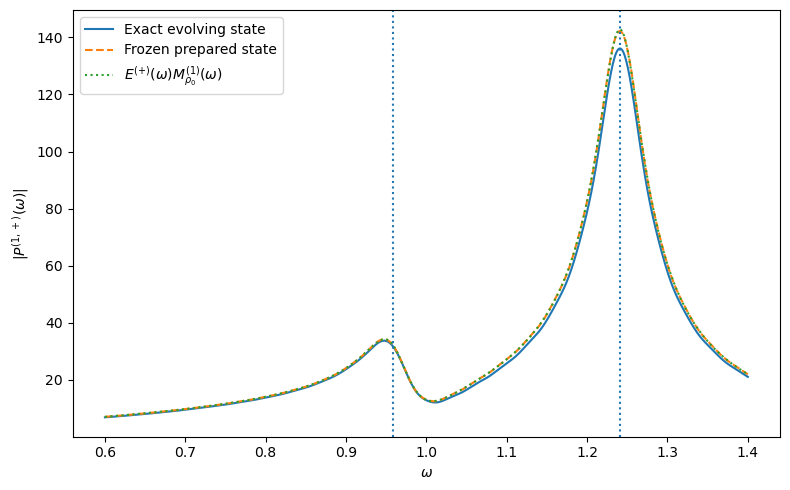

In [138]:
plt.figure(figsize=(8, 5))

plt.plot(
    omega_grid,
    np.abs(P1_prepared_exact_omega),
    label="Exact evolving state"
)

plt.plot(
    omega_grid,
    np.abs(P1_prepared_frozen_omega),
    "--",
    label="Frozen prepared state"
)

plt.plot(
    omega_grid,
    np.abs(P1_prepared_fd),
    ":",
    label=r"$E^{(+)}(\omega)M_{\rho_0}^{(1)}(\omega)$"
)

plt.axvline(
    omega_minus,
    linestyle=":"
)

plt.axvline(
    omega_plus,
    linestyle=":"
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$|P^{(1,+)}(\omega)|$")

plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "linear_prepared_state_comparison.pdf",
    bbox_inches="tight"
)

plt.show()